# Principal Component Analysis (PCA)
### From first principles: covariance, eigendecomposition, and projection

*A self-contained guide for anyone who knows Python and basic linear algebra.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display

np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

## 1 · Motivation: Why Reduce Dimensions?

Real-world data is often **high-dimensional**: a 100×100 grayscale image has 10,000 features per sample.
High dimensionality causes several problems:

- **Curse of dimensionality**: data becomes sparse; distances lose meaning
- **Redundancy**: correlated features carry duplicate information
- **Cost**: training and inference are expensive in high dimensions
- **Visualization**: we can only directly see 2D or 3D data

> **Key insight:** If features are correlated, the data actually lives in a lower-dimensional subspace.
> PCA finds that subspace.

**PCA's goal**: find the directions in which data *varies the most*, and project data onto those directions.

---

## 2 · The Covariance Matrix

### What is covariance?

For two zero-mean variables $x$ and $y$ over $n$ samples, covariance measures how they vary *together*:

$$\text{Cov}(x, y) = \frac{1}{n-1} \sum_{i=1}^n x_i y_i$$

- **Positive**: $x$ and $y$ tend to increase together
- **Negative**: when $x$ increases, $y$ tends to decrease
- **Zero**: they vary independently

### The Covariance Matrix

For a data matrix $\mathbf{X} \in \mathbb{R}^{n \times d}$ (n samples, d features), after **centering**
(subtracting the mean of each feature), $\tilde{\mathbf{X}} = \mathbf{X} - \bar{\mathbf{x}}$:

$$\mathbf{C} = \frac{1}{n-1} \tilde{\mathbf{X}}^T \tilde{\mathbf{X}} \in \mathbb{R}^{d \times d}$$

| Entry | Meaning |
|-------|----------|
| $C_{ii}$ | Variance of feature $i$ |
| $C_{ij}$ ($i \ne j$) | Covariance between features $i$ and $j$ |

### Properties

- **Symmetric**: $\mathbf{C} = \mathbf{C}^T$ (since $C_{ij} = C_{ji}$)
- **Positive semi-definite**: $\mathbf{v}^T \mathbf{C} \mathbf{v} \ge 0$ for all $\mathbf{v}$ (all eigenvalues $\ge 0$)

> **Key insight:** The covariance matrix encodes *all pairwise relationships* between features.
> PCA extracts the structure encoded in this matrix.

---

In [2]:
# Demonstrate covariance matrix computation from scratch
np.random.seed(42)
n_demo = 300

cov_true = np.array([[3.0, 1.8],
                     [1.8, 1.5]])
X_demo = np.random.multivariate_normal([0, 0], cov_true, n_demo)

# Step 1: center
X_c = X_demo - X_demo.mean(axis=0)

# Step 2: covariance from scratch
C_scratch = (X_c.T @ X_c) / (n_demo - 1)

print("True covariance matrix used to generate data:")
print(cov_true)
print("\nComputed covariance matrix (from scratch):")
print(C_scratch.round(3))
print("\nNumpy verification (np.cov):")
print(np.cov(X_c.T).round(3))

True covariance matrix used to generate data:
[[3.  1.8]
 [1.8 1.5]]

Computed covariance matrix (from scratch):
[[2.888 1.724]
 [1.724 1.42 ]]

Numpy verification (np.cov):
[[2.888 1.724]
 [1.724 1.42 ]]


## 3 · Eigendecomposition: Finding the Principal Directions

### The optimization problem

We want to find a unit vector $\mathbf{v}$ ($\|\mathbf{v}\| = 1$) that **maximizes variance** after projection.
The variance of the projected data $\tilde{\mathbf{X}}\mathbf{v}$ is:

$$\text{Var}(\tilde{\mathbf{X}}\mathbf{v}) = \mathbf{v}^T \mathbf{C} \mathbf{v}$$

We maximize this subject to $\|\mathbf{v}\|^2 = 1$.

### Lagrangian derivation

Form the Lagrangian: $\mathcal{L}(\mathbf{v}, \lambda) = \mathbf{v}^T \mathbf{C} \mathbf{v} - \lambda(\mathbf{v}^T\mathbf{v} - 1)$

Set the gradient to zero:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{v}} = 2\mathbf{C}\mathbf{v} - 2\lambda\mathbf{v} = 0$$

$$\Rightarrow \mathbf{C}\mathbf{v} = \lambda\mathbf{v}$$

This is the **eigenvalue equation**! The optimal direction $\mathbf{v}$ is an **eigenvector** of $\mathbf{C}$,
and the achieved variance equals the corresponding **eigenvalue** $\lambda$:

$$\mathbf{v}^T \mathbf{C} \mathbf{v} = \mathbf{v}^T (\lambda \mathbf{v}) = \lambda$$

> **Key insight:** Larger eigenvalue = more variance captured. Sort eigenvectors by eigenvalue (descending)
> to rank directions by importance.

### Full decomposition

$$\mathbf{C} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$$

| Symbol | Shape | Meaning |
|--------|-------|---------|
| $\mathbf{V}$ | $d \times d$ | Columns are eigenvectors (orthonormal: $\mathbf{V}^T\mathbf{V} = \mathbf{I}$) |
| $\mathbf{\Lambda}$ | $d \times d$ | Diagonal matrix of eigenvalues, sorted $\lambda_1 \ge \lambda_2 \ge \ldots \ge \lambda_d \ge 0$ |
| $\mathbf{V}_k$ | $d \times k$ | First $k$ columns of $\mathbf{V}$ — the top-$k$ principal directions |

---

## 4 · Dataset

We use two synthetic datasets:

1. **2D correlated Gaussian** — perfect for visualizing principal directions as arrows on a scatter plot
2. **Low-rank high-dimensional data** — 500 samples, 20 features, but truly only 3-dimensional structure
   (3 latent factors + noise)

---

In [3]:
np.random.seed(42)

# --- Dataset 1: 2D correlated Gaussian ---
n_2d = 300
cov_2d = np.array([[3.0, 1.8],
                   [1.8, 1.5]])
X_2d = np.random.multivariate_normal(mean=[2.0, 1.0], cov=cov_2d, size=n_2d)

print(f"Dataset 1 — 2D shape: {X_2d.shape}")
print(f"  Mean: {X_2d.mean(axis=0).round(3)}")
print(f"  Std:  {X_2d.std(axis=0).round(3)}")

# --- Dataset 2: Low-rank high-dimensional data ---
n_hd, d_hd, k_true = 500, 20, 3
np.random.seed(7)
Z_latent = np.random.randn(n_hd, k_true)          # true 3D coordinates
A_mix    = np.random.randn(k_true, d_hd) * 2.0    # mixing matrix
noise    = np.random.randn(n_hd, d_hd) * 0.5
X_hd     = Z_latent @ A_mix + noise

print(f"\nDataset 2 — High-dim shape: {X_hd.shape}")
print(f"  True intrinsic dimensionality: {k_true}")

Dataset 1 — 2D shape: (300, 2)
  Mean: [2.023 1.005]
  Std:  [1.697 1.19 ]

Dataset 2 — High-dim shape: (500, 20)
  True intrinsic dimensionality: 3


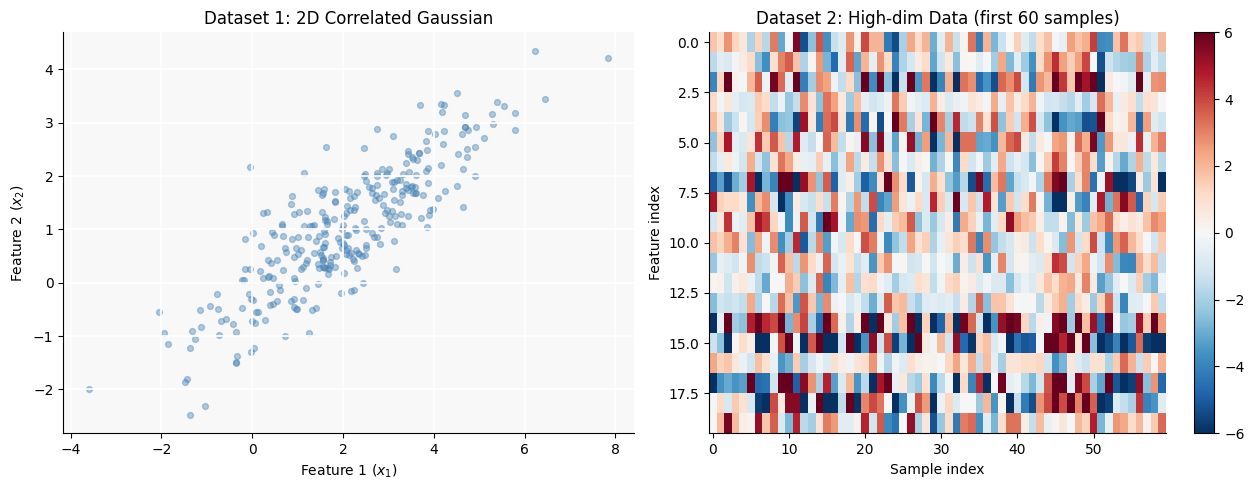

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.4, s=18, color='steelblue')
ax.set_xlabel("Feature 1 ($x_1$)")
ax.set_ylabel("Feature 2 ($x_2$)")
ax.set_title("Dataset 1: 2D Correlated Gaussian")

ax = axes[1]
im = ax.imshow(X_hd[:60].T, aspect='auto', cmap='RdBu_r', vmin=-6, vmax=6)
ax.set_xlabel("Sample index")
ax.set_ylabel("Feature index")
ax.set_title("Dataset 2: High-dim Data (first 60 samples)")
plt.colorbar(im, ax=ax)
ax.grid(False)

plt.tight_layout()
plt.show()

## 5 · PCA from Scratch

### The algorithm

Given $\mathbf{X} \in \mathbb{R}^{n \times d}$:

| Step | Operation | Result |
|------|-----------|--------|
| 1 | **Center**: subtract column means | $\tilde{\mathbf{X}} = \mathbf{X} - \bar{\mathbf{x}}$ |
| 2 | **Covariance**: $\mathbf{C} = \frac{1}{n-1}\tilde{\mathbf{X}}^T\tilde{\mathbf{X}}$ | $\mathbf{C} \in \mathbb{R}^{d \times d}$ |
| 3 | **Eigendecompose** and sort descending | $\mathbf{V}, \boldsymbol{\lambda}$ |
| 4 | **Select** top-$k$ eigenvectors | $\mathbf{V}_k \in \mathbb{R}^{d \times k}$ |
| 5 | **Project**: $\mathbf{Z} = \tilde{\mathbf{X}} \mathbf{V}_k$ | $\mathbf{Z} \in \mathbb{R}^{n \times k}$ |
| 6 | **Reconstruct**: $\hat{\mathbf{X}} = \mathbf{Z} \mathbf{V}_k^T + \bar{\mathbf{x}}$ | $\hat{\mathbf{X}} \in \mathbb{R}^{n \times d}$ |

> **Key insight:** Reconstruction is an approximation when $k < d$. The reconstruction error equals the
> sum of the *discarded* eigenvalues — and PCA is the **optimal** linear compressor for any given $k$.

---

In [5]:
class PCA:
    """PCA via eigendecomposition of the covariance matrix."""

    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None           # shape (n_components, d)
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        n, d = X.shape

        # Step 1: center
        self.mean_ = X.mean(axis=0)
        X_c = X - self.mean_

        # Step 2: covariance matrix
        C = (X_c.T @ X_c) / (n - 1)

        # Step 3: eigendecomposition (eigh exploits symmetry; returns sorted ascending)
        eigenvalues, eigenvectors = np.linalg.eigh(C)

        # Sort descending
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.explained_variance_       = eigenvalues
        self.explained_variance_ratio_ = eigenvalues / eigenvalues.sum()

        # Step 4: keep top k  →  stored as rows for convenient matrix multiply
        self.components_ = eigenvectors[:, :self.n_components].T   # (k, d)
        return self

    def transform(self, X):
        return (X - self.mean_) @ self.components_.T    # (n, k)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_        # (n, d)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [6]:
# Fit on 2D dataset (keep both components)
pca_2d = PCA(n_components=2)
pca_2d.fit(X_2d)

print("=== PCA on 2D Dataset ===")
print(f"\nData mean: {pca_2d.mean_.round(3)}")
print("\nEigenvalues (= variance per PC):")
for i, (ev, ratio) in enumerate(zip(pca_2d.explained_variance_,
                                    pca_2d.explained_variance_ratio_)):
    print(f"  PC{i+1}: λ = {ev:.4f}  ({ratio*100:.1f}% of total variance)")

print("\nPrincipal components (rows = eigenvectors):")
print(pca_2d.components_.round(4))

# Fit on high-dimensional dataset
pca_hd = PCA(n_components=X_hd.shape[1])
pca_hd.fit(X_hd)

print(f"\n=== PCA on {X_hd.shape[1]}-dim Dataset ===")
print("Cumulative variance explained:")
cumvar = np.cumsum(pca_hd.explained_variance_ratio_)
for k in [1, 2, 3, 5, 10]:
    print(f"  Top {k:2d} PCs: {cumvar[k-1]*100:.1f}%")

=== PCA on 2D Dataset ===

Data mean: [2.023 1.005]

Eigenvalues (= variance per PC):
  PC1: λ = 4.0278  (93.5% of total variance)
  PC2: λ = 0.2803  (6.5% of total variance)

Principal components (rows = eigenvectors):
[[-0.8342 -0.5515]
 [ 0.5515 -0.8342]]

=== PCA on 20-dim Dataset ===
Cumulative variance explained:
  Top  1 PCs: 39.5%
  Top  2 PCs: 76.8%
  Top  3 PCs: 98.2%
  Top  5 PCs: 98.5%
  Top 10 PCs: 99.1%


## 6 · Visualizing Principal Components

Principal components are *directions* in feature space. Drawn as arrows on the scatter plot:

- **Direction**: where the data stretches
- **Length**: scaled by $\sqrt{\lambda}$ (one standard deviation along that PC)
- **Orthogonality**: PC2 is always perpendicular to PC1

After projection, the new axes are the PCs — data is **decorrelated** (covariance matrix is diagonal in PC space).

---

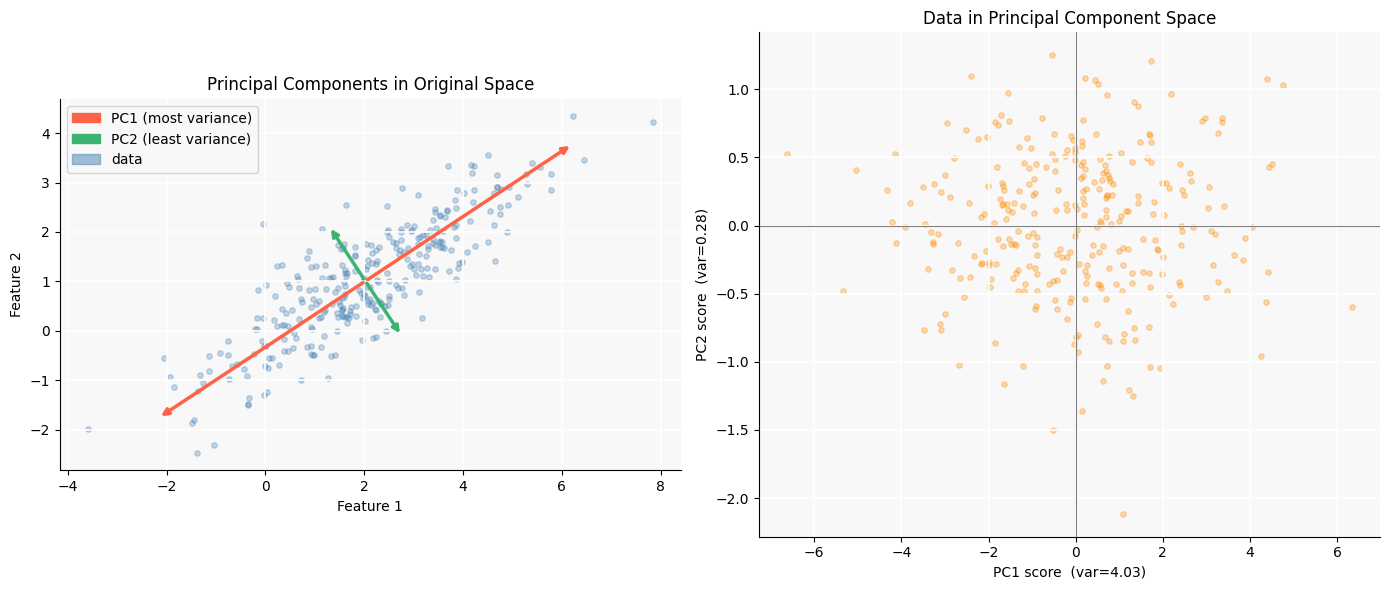

Covariance matrix in PC space (should be diagonal):
[[ 4.0278 -0.    ]
 [-0.      0.2803]]


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: original space with eigenvector arrows ---
ax = axes[0]
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, s=15, color='steelblue', label='data')

origin = pca_2d.mean_
pc_colors = ['tomato', 'mediumseagreen']
pc_labels = ['PC1 (most variance)', 'PC2 (least variance)']

for i, (color, label) in enumerate(zip(pc_colors, pc_labels)):
    vec   = pca_2d.components_[i]                          # unit eigenvector
    scale = np.sqrt(pca_2d.explained_variance_[i]) * 2.5  # 2.5σ arrow length
    arrow_kw = dict(arrowstyle="-|>", color=color, lw=2.5)
    ax.annotate("", xy=origin + scale * vec, xytext=origin,
                arrowprops=arrow_kw)
    ax.annotate("", xy=origin - scale * vec, xytext=origin,
                arrowprops=arrow_kw)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Principal Components in Original Space")
handles = [mpatches.Patch(color=c, label=l) for c, l in zip(pc_colors, pc_labels)]
handles.append(mpatches.Patch(color='steelblue', alpha=0.5, label='data'))
ax.legend(handles=handles)
ax.set_aspect('equal')

# --- Right: projected PC space ---
Z_2d = pca_2d.transform(X_2d)
ax = axes[1]
ax.scatter(Z_2d[:, 0], Z_2d[:, 1], alpha=0.3, s=15, color='darkorange')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel(f"PC1 score  (var={pca_2d.explained_variance_[0]:.2f})")
ax.set_ylabel(f"PC2 score  (var={pca_2d.explained_variance_[1]:.2f})")
ax.set_title("Data in Principal Component Space")

plt.tight_layout()
plt.show()

cov_pc = np.cov(Z_2d.T)
print(f"Covariance matrix in PC space (should be diagonal):")
print(cov_pc.round(4))

## 7 · Variance Explained — The Scree Plot

The **explained variance ratio** for PC $i$:

$$r_i = \frac{\lambda_i}{\sum_{j=1}^d \lambda_j}$$

The **cumulative explained variance** after $k$ components:

$$R_k = \sum_{i=1}^k r_i$$

A **scree plot** shows $\lambda_i$ vs. component index. The "elbow" (sharp drop followed by a plateau)
indicates the true intrinsic dimensionality of the data.

> **Key insight:** In our high-dim dataset with 3 latent factors, eigenvalues 1–3 should be much
> larger than the rest (which capture only noise).

---

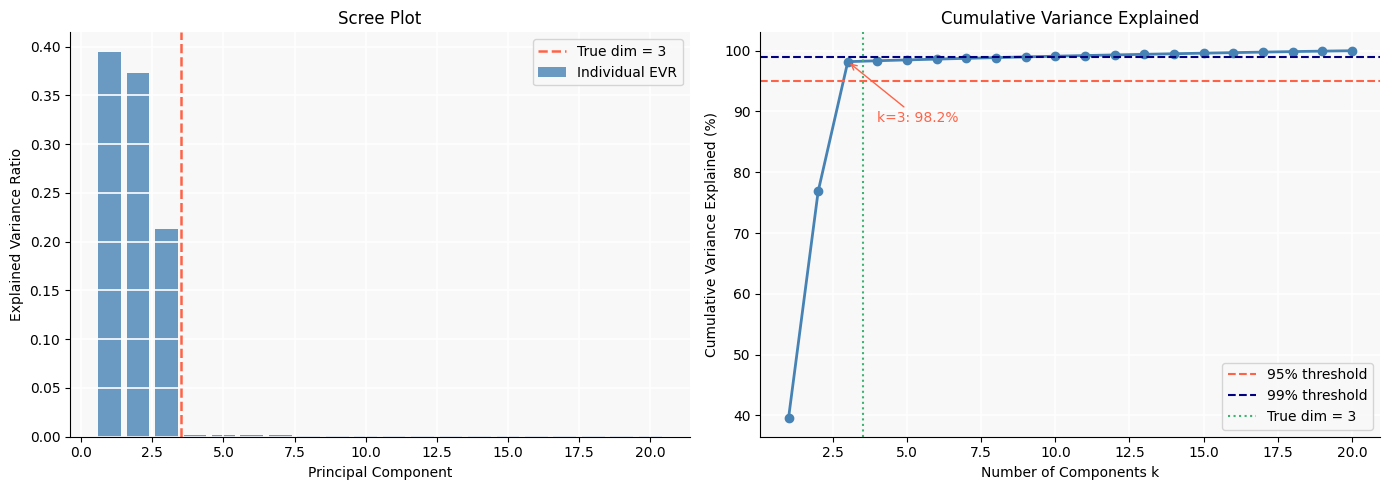

In [8]:
evr = pca_hd.explained_variance_ratio_
cumvar = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: individual explained variance (scree plot) ---
ax = axes[0]
ax.bar(range(1, len(evr)+1), evr, color='steelblue', alpha=0.8, label='Individual EVR')
ax.axvline(3.5, color='tomato', lw=1.8, linestyle='--', label='True dim = 3')
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Scree Plot")
ax.legend()

# --- Right: cumulative explained variance ---
ax = axes[1]
ax.plot(range(1, len(cumvar)+1), cumvar * 100, 'o-', color='steelblue', lw=2, ms=6)
ax.axhline(95, color='tomato', lw=1.5, linestyle='--', label='95% threshold')
ax.axhline(99, color='navy',   lw=1.5, linestyle='--', label='99% threshold')
ax.axvline(3.5, color='mediumseagreen', lw=1.5, linestyle=':', label='True dim = 3')

idx_95 = int(np.searchsorted(cumvar, 0.95))
ax.annotate(f'k={idx_95+1}: {cumvar[idx_95]*100:.1f}%',
            xy=(idx_95+1, cumvar[idx_95]*100),
            xytext=(idx_95+2, cumvar[idx_95]*100 - 10),
            arrowprops=dict(arrowstyle='->', color='tomato'), color='tomato', fontsize=10)

ax.set_xlabel("Number of Components k")
ax.set_ylabel("Cumulative Variance Explained (%)")
ax.set_title("Cumulative Variance Explained")
ax.legend()

plt.tight_layout()
plt.show()

## 8 · Projection & Reconstruction

### Projection (encoding)

$$\mathbf{Z} = \tilde{\mathbf{X}} \mathbf{V}_k \in \mathbb{R}^{n \times k}$$

Each row of $\mathbf{Z}$ is a sample's coordinates in the $k$-dimensional PC space.

### Reconstruction (decoding)

$$\hat{\mathbf{X}} = \mathbf{Z} \mathbf{V}_k^T + \bar{\mathbf{x}} \in \mathbb{R}^{n \times d}$$

### Reconstruction MSE

The mean squared error equals the sum of the *discarded* eigenvalues divided by $d$:

$$\text{MSE}(k) = \frac{1}{nd}\|\mathbf{X} - \hat{\mathbf{X}}\|_F^2 = \frac{1}{d}\sum_{i=k+1}^d \lambda_i$$

> **Key insight:** No other linear $k$-dimensional subspace achieves lower reconstruction MSE —
> PCA is the **optimal** linear autoencoder.

---

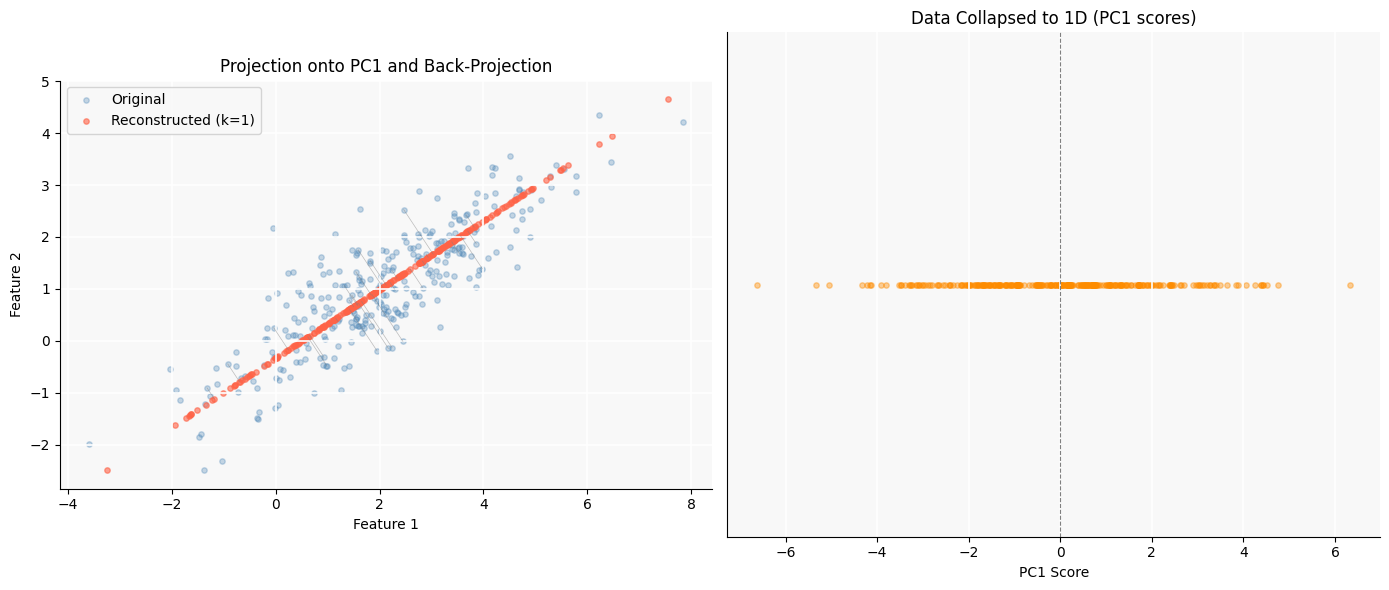

Reconstruction MSE (computed):    0.1397
Reconstruction MSE (theoretical): 0.1401   (= discarded λ / d)


In [9]:
# Project 2D data onto 1D then reconstruct back to 2D
pca_1d = PCA(n_components=1)
Z_1d     = pca_1d.fit_transform(X_2d)
X_recon  = pca_1d.inverse_transform(Z_1d)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: original vs reconstructed with residual lines ---
ax = axes[0]
ax.scatter(X_2d[:, 0],   X_2d[:, 1],   alpha=0.3, s=15, color='steelblue', label='Original')
ax.scatter(X_recon[:, 0], X_recon[:, 1], alpha=0.6, s=15, color='tomato',    label='Reconstructed (k=1)')

for i in range(0, 80, 3):   # residual lines for a subset
    ax.plot([X_2d[i,0], X_recon[i,0]], [X_2d[i,1], X_recon[i,1]],
            color='gray', lw=0.5, alpha=0.5)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("Projection onto PC1 and Back-Projection")
ax.legend()
ax.set_aspect('equal')

# --- Right: 1D projection ---
ax = axes[1]
ax.scatter(Z_1d[:, 0], np.zeros(len(Z_1d)), alpha=0.4, s=15, color='darkorange')
ax.set_xlabel("PC1 Score")
ax.set_yticks([])
ax.set_title("Data Collapsed to 1D (PC1 scores)")
ax.axvline(0, color='gray', lw=0.8, linestyle='--')

plt.tight_layout()
plt.show()

mse_computed    = np.mean((X_2d - X_recon)**2)
mse_theoretical = pca_1d.explained_variance_[1] / X_2d.shape[1]   # discarded λ / d
print(f"Reconstruction MSE (computed):    {mse_computed:.4f}")
print(f"Reconstruction MSE (theoretical): {mse_theoretical:.4f}   (= discarded λ / d)")

## 9 · Effect of k — How Many Components?

The choice of $k$ controls the compression–fidelity trade-off:

| Larger $k$ | Smaller $k$ |
|------------|-------------|
| Better reconstruction | More compression |
| Slower downstream models | Faster downstream models |
| Less noise filtering | More regularization (noise removed) |

**Common selection strategies:**
- **Elbow rule**: find the knee in the scree plot
- **Variance threshold**: smallest $k$ such that $R_k \ge 95\%$ (or 99\%)
- **Task-driven**: choose $k$ maximizing a downstream metric

---

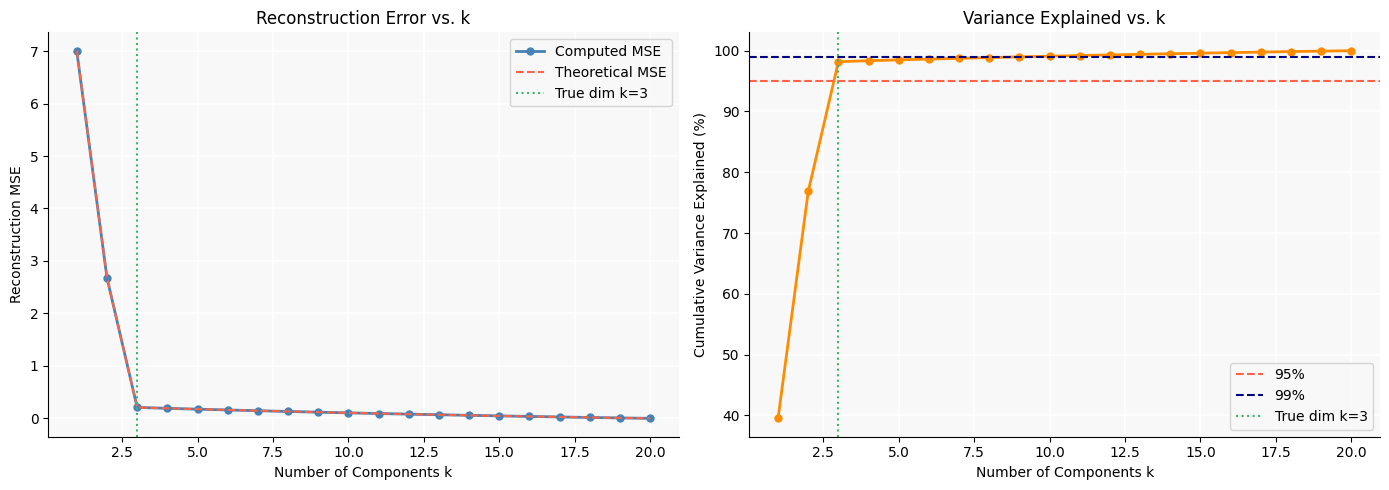

In [10]:
ks      = list(range(1, d_hd + 1))
mse_ks  = []

for k in ks:
    p   = PCA(n_components=k)
    Z_k = p.fit_transform(X_hd)
    mse_ks.append(np.mean((X_hd - p.inverse_transform(Z_k))**2))

# Theoretical MSE_k = sum(discarded eigenvalues) / d
all_ev = pca_hd.explained_variance_
mse_theory = [all_ev[k:].sum() / d_hd for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ks, mse_ks,     'o-',  color='steelblue', lw=2,   ms=5, label='Computed MSE')
ax.plot(ks, mse_theory, '--',  color='tomato',    lw=1.5,       label='Theoretical MSE')
ax.axvline(3, color='mediumseagreen', lw=1.5, linestyle=':', label='True dim k=3')
ax.set_xlabel("Number of Components k")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("Reconstruction Error vs. k")
ax.legend()

ax = axes[1]
cumvar_pct = np.cumsum(pca_hd.explained_variance_ratio_) * 100
ax.plot(ks, cumvar_pct, 'o-', color='darkorange', lw=2, ms=5)
ax.axhline(95, color='tomato', lw=1.5, linestyle='--', label='95%')
ax.axhline(99, color='navy',   lw=1.5, linestyle='--', label='99%')
ax.axvline(3, color='mediumseagreen', lw=1.5, linestyle=':', label='True dim k=3')
ax.set_xlabel("Number of Components k")
ax.set_ylabel("Cumulative Variance Explained (%)")
ax.set_title("Variance Explained vs. k")
ax.legend()

plt.tight_layout()
plt.show()

## 10 · Interactive: Reconstruction Quality vs. k

Use the slider to vary $k$ and observe:

- How the reconstructed heatmap compares to the original
- How quickly MSE drops — notice the biggest gain at $k = 1, 2, 3$ (the true latent dimension)

---

In [ ]:
def plot_reconstruction(k):
    p     = PCA(n_components=k)
    Z_k   = p.fit_transform(X_hd)
    X_hat = p.inverse_transform(Z_k)
    mse   = np.mean((X_hd - X_hat)**2)
    var_exp = np.cumsum(pca_hd.explained_variance_ratio_)[k-1] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, data, title in zip(
        axes,
        [X_hd[:60], X_hat[:60]],
        ["Original", f"Reconstructed  k={k}  |  MSE={mse:.3f}  |  Var={var_exp:.1f}%"]
    ):
        im = ax.imshow(data.T, aspect='auto', cmap='RdBu_r', vmin=-6, vmax=6)
        ax.set_title(title)
        ax.set_xlabel("Sample")
        ax.set_ylabel("Feature")
        ax.grid(False)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


k_slider = widgets.IntSlider(
    value=3, min=1, max=d_hd, step=1,
    description='k (# PCs):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='60%')
)
widgets.interact(plot_reconstruction, k=k_slider)

interactive(children=(IntSlider(value=3, description='k (# PCs):', layout=Layout(width='60%'), max=20, min=1, …

<function __main__.plot_reconstruction(k)>

---

## Summary

| Concept | Key Idea |
|---------|----------|
| **Dimensionality reduction** | Represent high-dim data in fewer dimensions while preserving variance |
| **Centering** | Subtract the mean so the origin is the data centroid — required before PCA |
| **Covariance matrix** $\mathbf{C}$ | Symmetric $d{\times}d$ matrix: $C_{ij}$ = covariance between features $i$ and $j$ |
| **Eigendecomposition** | Factorizes $\mathbf{C} = \mathbf{V}\mathbf{\Lambda}\mathbf{V}^T$; columns of $\mathbf{V}$ are principal directions |
| **Eigenvalue** $\lambda_i$ | Variance of data along the $i$-th principal component |
| **Principal component** | Eigenvector of $\mathbf{C}$; a direction of maximal (residual) variance |
| **Orthogonality** | All PCs are perpendicular — projections are decorrelated |
| **Projection** | $\mathbf{Z} = \tilde{\mathbf{X}}\mathbf{V}_k$ — lossless only if $k = d$ |
| **Reconstruction** | $\hat{\mathbf{X}} = \mathbf{Z}\mathbf{V}_k^T + \bar{\mathbf{x}}$ — approximate original space |
| **Explained variance ratio** | $r_i = \lambda_i / \sum \lambda_j$ — fraction of total variance captured by PC$i$ |
| **Scree plot** | Eigenvalues vs. index; elbow reveals intrinsic dimensionality |
| **Reconstruction MSE** | $= \frac{1}{d}\sum_{i>k}\lambda_i$ — PCA is the optimal linear compressor for any $k$ |
| **Choosing $k$** | Elbow rule, variance threshold (95%/99%), or downstream task performance |